# Prédiction de routes aériennes avec un VGAE

**Objectif :** prédire l'existence de routes aériennes (arêtes) entre aéroports (nœuds) avec un auto-encodeur variationnel de graphe (VGAE).

**Plan du notebook :**
0. Préparation : imports, données et fonctions communes
1. Baseline : distance géographique
2. VGAE-GCN avec 3 dimensions différentes
3. GCN, GAT et SAGE à dimensions égales
4. Amélioration des features : brutes → normalisées → 3D → 3D + pays
5. Synthèse

Sauf mention contraire, tous les modèles sont entraînés dans les mêmes conditions : `lr = 0.01`, 200 époques, 3 seeds. On garde l'époque avec la meilleure AUC de validation, puis on mesure l'**AUC** et l'**AP** sur le **test**.

## 0. Préparation

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as th
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GATConv, GCNConv, SAGEConv

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
# Données générées par le notebook 0 (split train / val / test fait avec RandomLinkSplit)
train_data = th.load('../data/train_data.pt', weights_only=False)
val_data = th.load('../data/val_data.pt', weights_only=False)
test_data = th.load('../data/test_data.pt', weights_only=False)
data = th.load('../data/data.pt', weights_only=False)

print(test_data)
print(f"\nFeatures des nœuds : [longitude, latitude, population] -> {data.num_features} features")

# Paramètres communs à toutes les expériences
HIDDEN, DIM_OUT, EPOCHS, LR = 32, 16, 200, 0.01
SEEDS = [0, 1, 2]

Data(edge_index=[2, 21676], country=[3363], city_name=[3363], x=[3363, 3], pos_edge_label=[2709], pos_edge_label_index=[2, 2709], neg_edge_label=[2709], neg_edge_label_index=[2, 2709])

Features des nœuds : [longitude, latitude, population] -> 3 features


### Fonctions communes

- **`Encoder`** : calcule $\mu$ et $\log\sigma$ de la distribution latente de chaque nœud. Le type de couche (`conv`) est un paramètre : `GCNConv` par défaut, `GATConv` ou `SAGEConv` en section 3.
- **`entrainer_et_tester`** : entraîne le VGAE (loss = reconstruction + KL / nombre de nœuds), garde l'époque avec la meilleure AUC de validation, puis renvoie l'AUC et l'AP sur le test.
- **`lancer_experience`** : répète l'entraînement pour chaque seed.
- **`resumer`, `tracer_barres`, `tracer_loss`, `afficher_matrice_confusion`** : tableaux et graphiques.

In [3]:
class Encoder(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out, conv=GCNConv):
        super(Encoder, self).__init__()
        self.conv1 = conv(dim_in, hidden_channels)
        self.conv_mu = conv(hidden_channels, dim_out)
        self.conv_logstd = conv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(x, edge_index)
        logstd = self.conv_logstd(x, edge_index)
        return mu, logstd


def entrainer_et_tester(model, optimizer, epochs, train_data, val_data, test_data):
    history = {"train": [], "val": []}
    meilleure_auc_val, meilleur_etat = -1, None
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        loss = model.recon_loss(
            z, train_data.pos_edge_label_index, train_data.neg_edge_label_index
        ) + model.kl_loss() / train_data.num_nodes
        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())

        # validation : pas de calcul de gradient
        model.eval()
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            val_loss = model.recon_loss(
                z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index
            ) + model.kl_loss() / val_data.num_nodes
            history["val"].append(val_loss.item())
            auc_val, _ = model.test(z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index)
            if auc_val > meilleure_auc_val:
                meilleure_auc_val, meilleur_etat = auc_val, copy.deepcopy(model.state_dict())

    # évaluation sur le test avec le meilleur modèle (choisi sur la validation)
    model.load_state_dict(meilleur_etat)
    model.eval()
    with th.no_grad():
        z_test = model.encode(test_data.x, test_data.edge_index)
        auc_test, ap_test = model.test(z_test, test_data.pos_edge_label_index, test_data.neg_edge_label_index)
    return history, auc_test, ap_test


def lancer_experience(splits, conv=GCNConv, hidden_channels=HIDDEN, dim_out=DIM_OUT):
    # un entraînement par seed ; renvoie les résultats test, l'historique et le modèle de la première seed
    resultats, historique, modele = [], None, None
    for seed in SEEDS:
        th.manual_seed(seed)
        model = VGAE(Encoder(splits[0].num_features, hidden_channels, dim_out, conv))
        optimizer = th.optim.Adam(model.parameters(), lr=LR)
        history, auc, ap = entrainer_et_tester(model, optimizer, EPOCHS, *splits)
        resultats.append({"seed": seed, "AUC": auc, "AP": ap})
        if seed == SEEDS[0]:
            historique, modele = history, model
    return resultats, historique, modele

In [4]:
def resumer(df, colonnes):
    # moyenne et écart-type sur les seeds
    return df.groupby(colonnes, sort=False)[["AUC", "AP"]].agg(["mean", "std"]).round(4)


def tracer_barres(df, col_groupe, col_serie=None, titre="", ylim=(0.4, 1.03)):
    # barres AUC / AP (moyenne ± écart-type sur les seeds) + ligne de la baseline distance (section 1)
    if col_serie is None:
        df = df.assign(_serie="VGAE")
        col_serie = "_serie"
    stats = df.groupby([col_groupe, col_serie], sort=False)[["AUC", "AP"]].agg(["mean", "std"])
    groupes = list(dict.fromkeys(df[col_groupe]))
    series = list(dict.fromkeys(df[col_serie]))
    largeur = 0.8 / len(series)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metrique in zip(axes, ["AUC", "AP"]):
        for i, serie in enumerate(series):
            positions = [g + (i - (len(series) - 1) / 2) * largeur for g in range(len(groupes))]
            moyennes = [stats.loc[(g, serie), (metrique, "mean")] for g in groupes]
            ecarts = [stats.loc[(g, serie), (metrique, "std")] for g in groupes]
            barres = ax.bar(positions, moyennes, largeur, yerr=ecarts, capsize=3,
                            label=serie if col_serie != "_serie" else None)
            ax.bar_label(barres, fmt="%.3f", padding=3, fontsize=7)
        ax.axhline(baseline[metrique], color="#c62828", linestyle="--", linewidth=1, label="baseline distance")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="hasard")
        ax.set_xticks(range(len(groupes)), groupes)
        ax.set_ylim(*ylim)
        ax.set_title(f"{metrique} test — {titre}")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, fontsize=8)
    plt.tight_layout()
    plt.show()


def tracer_loss(historiques, titre):
    # courbes de loss train (trait plein) et validation (pointillés), échelle log
    plt.figure(figsize=(8, 4))
    for nom, history in historiques.items():
        ligne, = plt.plot(history["train"], label=f"{nom} train")
        plt.plot(history["val"], linestyle="--", color=ligne.get_color(), label=f"{nom} val")
    plt.yscale("log")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (échelle log)")
    plt.title(titre)
    plt.legend(fontsize=8)
    plt.show()


def afficher_matrice_confusion(lemodele, donnees_testees, titre):
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    with th.no_grad():
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)

        # Récupération de toutes les arêtes positives et négatives
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf = lemodele.test(z, pos_edges, neg_edges)
        predictions = (probabilites >= 0.5).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {perf[0]:.4f} (vrai_positif/faux_positif) - AP {perf[1]:.4f} ( précision/rappel )")

## 1. Baseline : distance géographique

Une **baseline** est une méthode simple, sans apprentissage, à laquelle on compare les modèles. Elle répond à la question : *le VGAE apprend-il plus qu'une règle de bon sens ?*

**La règle :** deux aéroports proches ont plus de chances d'être reliés (vols régionaux, intérieurs). Pour chaque paire $(u, v)$ du test, on donne donc le score :

$$\text{score}(u, v) = -d(u, v)$$

On prend l'opposé de la distance car une **petite** distance doit donner un **grand** score.

**Calcul de la distance :** on utilise la distance à vol d'oiseau sur la sphère terrestre, avec la **formule de haversine**. Avec $\varphi$ la latitude et $\lambda$ la longitude **en radians**, et $R = 6371$ km le rayon de la Terre :

$$a = \sin^2\left(\frac{\varphi_v - \varphi_u}{2}\right) + \cos\varphi_u \cdot \cos\varphi_v \cdot \sin^2\left(\frac{\lambda_v - \lambda_u}{2}\right)$$

$$d(u, v) = 2R \cdot \arcsin\left(\sqrt{a}\right)$$

Une distance euclidienne sur (lon, lat) serait fausse : un degré de longitude vaut 111 km à l'équateur mais 0 km au pôle, et −179° et +179° sont voisins alors que leur différence vaut 358°.

**Évaluation :** on compare ces scores aux vraies réponses (1 = route existante, 0 = paire négative) avec les **mêmes métriques que le VGAE** (AUC et AP). Ces métriques ne dépendent que de l'**ordre** des scores : pas besoin de seuil ni de scores entre 0 et 1.

In [5]:
# Baseline : distance géographique (formule de haversine)

R_TERRE = 6371  # km

# x = [longitude, latitude, population] (features brutes) ; conversion des degrés en radians
longitude = np.radians(test_data.x[:, 0].numpy())
latitude = np.radians(test_data.x[:, 1].numpy())
villes = test_data.city_name

def distance_haversine(u, v):
    d_lat = latitude[v] - latitude[u]
    d_lon = longitude[v] - longitude[u]
    a = np.sin(d_lat / 2) ** 2 + np.cos(latitude[u]) * np.cos(latitude[v]) * np.sin(d_lon / 2) ** 2
    return 2 * R_TERRE * np.arcsin(np.sqrt(a))

# Paires du test : d'abord les vraies routes (label 1), puis les paires négatives (label 0)
paires_pos = test_data.pos_edge_label_index
paires_neg = test_data.neg_edge_label_index
u_test = th.cat([paires_pos[0], paires_neg[0]]).numpy()
v_test = th.cat([paires_pos[1], paires_neg[1]]).numpy()
labels_test = np.array([1] * paires_pos.size(1) + [0] * paires_neg.size(1))

# Calcul détaillé sur deux exemples : une vraie route et une paire négative
for titre, (u, v) in [("Vraie route", paires_pos[:, 0].tolist()), ("Paire négative", paires_neg[:, 0].tolist())]:
    print(f"{titre} : {villes[u]} - {villes[v]}")
    print(f"  {villes[u]} : lat = {np.degrees(latitude[u]):.2f}°, lon = {np.degrees(longitude[u]):.2f}°")
    print(f"  {villes[v]} : lat = {np.degrees(latitude[v]):.2f}°, lon = {np.degrees(longitude[v]):.2f}°")
    print(f"  distance = {distance_haversine(u, v):.0f} km -> score = {-distance_haversine(u, v):.0f}\n")

# Calcul pour toutes les paires du test (vectorisé : u_test et v_test sont des tableaux d'indices)
distances_test = distance_haversine(u_test, v_test)
print(f"Distance médiane : vraies routes = {np.median(distances_test[labels_test == 1]):.0f} km, "
      f"paires négatives = {np.median(distances_test[labels_test == 0]):.0f} km")

# Même calcul que model.test() du VGAE : AUC et AP à partir des scores et des labels
scores_distance = -distances_test
auc_distance = roc_auc_score(labels_test, scores_distance)
ap_distance = average_precision_score(labels_test, scores_distance)
print(f"\nBaseline distance : AUC = {auc_distance:.4f} - AP = {ap_distance:.4f}")

# référence utilisée dans tous les graphiques suivants (ligne rouge)
baseline = {"AUC": auc_distance, "AP": ap_distance}

Vraie route : Guatemala City - San Jose
  Guatemala City : lat = 14.58°, lon = -90.53°
  San Jose : lat = 10.00°, lon = -84.22°
  distance = 855 km -> score = -855

Paire négative : Beihai - Vanimo
  Beihai : lat = 21.48°, lon = 109.08°
  Vanimo : lat = -2.68°, lon = 141.30°
  distance = 4416 km -> score = -4416

Distance médiane : vraies routes = 847 km, paires négatives = 9126 km

Baseline distance : AUC = 0.9179 - AP = 0.9264


## 2. VGAE-GCN avec 3 dimensions différentes

On garde un encodeur GCN à 2 couches et on fait varier ses dimensions :
- `hidden_channels` : taille de la couche cachée
- `dim_out` : taille de l'espace latent $z$ (dimension de $\mu$ et $\log\sigma$)

| Modèle | hidden_channels | dim_out |
|---|---|---|
| model_a | 32 | 16 |
| model_b | 128 | 16 |
| model_c | 6 | 6 |

Les features sont les **features brutes** `[longitude, latitude, population]`.

In [6]:
splits_bruts = (train_data, val_data, test_data)
dimensions = {
    "model_a (32 → 16)": (32, 16),
    "model_b (128 → 16)": (128, 16),
    "model_c (6 → 6)": (6, 6),
}

resultats_dim, historiques_dim, modeles_dim = [], {}, {}
for nom, (hidden_channels, dim_out) in dimensions.items():
    resultats, historiques_dim[nom], modeles_dim[nom] = lancer_experience(
        splits_bruts, GCNConv, hidden_channels, dim_out)
    resultats_dim += [{"modele": nom, **r} for r in resultats]
    print(f"{nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))

df_dimensions = pd.DataFrame(resultats_dim)
resumer(df_dimensions, "modele")

model_a (32 → 16) : AUC test = 0.7223, 0.7347, 0.7299


model_b (128 → 16) : AUC test = 0.7301, 0.7360, 0.7379


model_c (6 → 6) : AUC test = 0.7317, 0.6944, 0.7423


AUC              AP        
                      mean     std    mean     std
modele                                            
model_a (32 → 16)   0.7290  0.0063  0.6499  0.0053
model_b (128 → 16)  0.7347  0.0041  0.6550  0.0041
model_c (6 → 6)     0.7228  0.0251  0.6451  0.0215

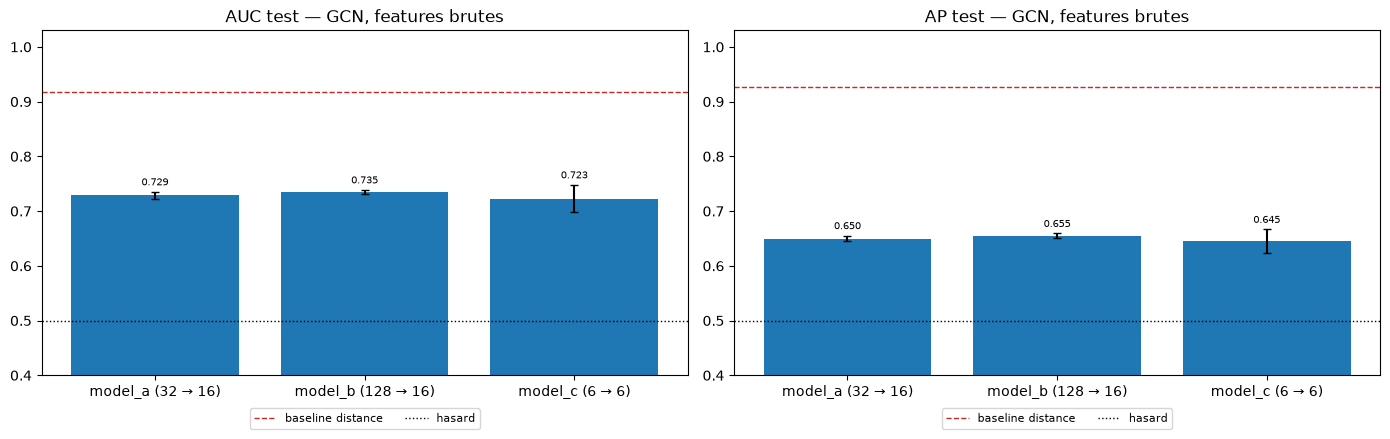

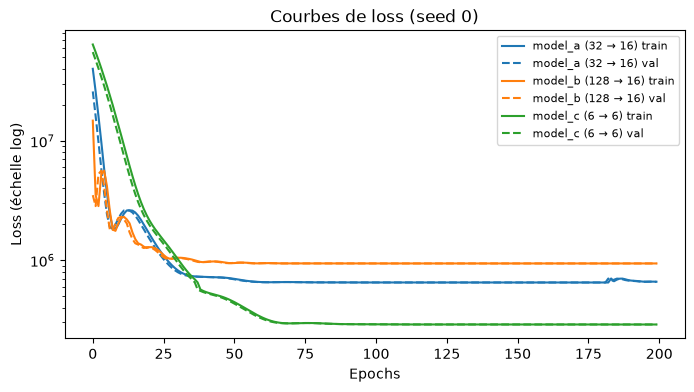


Matrice de confusion — model_a (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1258 1451]
 [  71 2638]]
Perf : AUC 0.7223 (vrai_positif/faux_positif) - AP 0.6443 ( précision/rappel )

Matrice de confusion — model_b (128 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1233 1476]
 [  41 2668]]
Perf : AUC 0.7301 (vrai_positif/faux_positif) - AP 0.6505 ( précision/rappel )

Matrice de confusion — model_c (6 → 6) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1307 1402]
 [  66 2643]]
Perf : AUC 0.7317 (vrai_positif/faux_positif) - AP 0.6521 ( précision/rappel )


In [7]:
tracer_barres(df_dimensions, "modele", titre="GCN, features brutes")
tracer_loss(historiques_dim, "Courbes de loss (seed 0)")
for nom, model in modeles_dim.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")

### Interprétation

- **Les dimensions changent très peu les résultats :** les trois modèles sont entre 0.72 et 0.74 d'AUC. model_b (128 → 16) est très légèrement meilleur, mais l'écart est du même ordre que la variation entre seeds.
- **model_c (6 → 6) est le moins stable** (écart-type ~0.025 contre ~0.005) : avec un très petit espace latent, le résultat dépend davantage de l'initialisation. Dans une version précédente (500 époques, sans sélection sur la validation), il ne dépassait pas le hasard (AUC 0.5) : garder l'époque avec la meilleure AUC de validation le rend utilisable.
- **Tous les modèles sont loin sous la baseline distance (0.918)** : augmenter la capacité du modèle ne suffit pas. Le problème vient plutôt des **features** (section 4).
- **Matrices de confusion :** avec un seuil à 0.5, le modèle prédit « route » pour plus de la moitié des paires négatives (~1 450 faux positifs sur 2 709). Les probabilités sont mal calibrées. L'AUC et l'AP, elles, ne dépendent pas du seuil.

## 3. GCN, GAT et SAGE à dimensions égales

On fixe les dimensions (`hidden=32`, `dim_out=16`, comme model_a) et les features (brutes) : **seule la couche de message passing change**.

- **GCN** : agrégation des voisins normalisée par le degré
- **GAT** : agrégation pondérée par des coefficients d'attention appris
- **SAGE** : transformation séparée du nœud et de la moyenne de ses voisins

Le GCN de cette section est exactement le model_a de la section 2 (même configuration, mêmes seeds) : on retrouve donc les mêmes résultats.

In [8]:
convs = {"GCN": GCNConv, "GAT": GATConv, "SAGE": SAGEConv}

resultats_convs, historiques_convs, modeles_convs = [], {}, {}
for nom, conv in convs.items():
    resultats, historiques_convs[nom], modeles_convs[nom] = lancer_experience(splits_bruts, conv)
    resultats_convs += [{"couche": nom, **r} for r in resultats]
    print(f"{nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))

df_convs = pd.DataFrame(resultats_convs)
resumer(df_convs, "couche")

GCN : AUC test = 0.7223, 0.7347, 0.7299


GAT : AUC test = 0.5752, 0.5125, 0.6208


SAGE : AUC test = 0.5816, 0.5439, 0.5557


AUC              AP        
          mean     std    mean     std
couche                                
GCN     0.7290  0.0063  0.6499  0.0053
GAT     0.5695  0.0543  0.5387  0.0314
SAGE    0.5604  0.0193  0.5328  0.0116

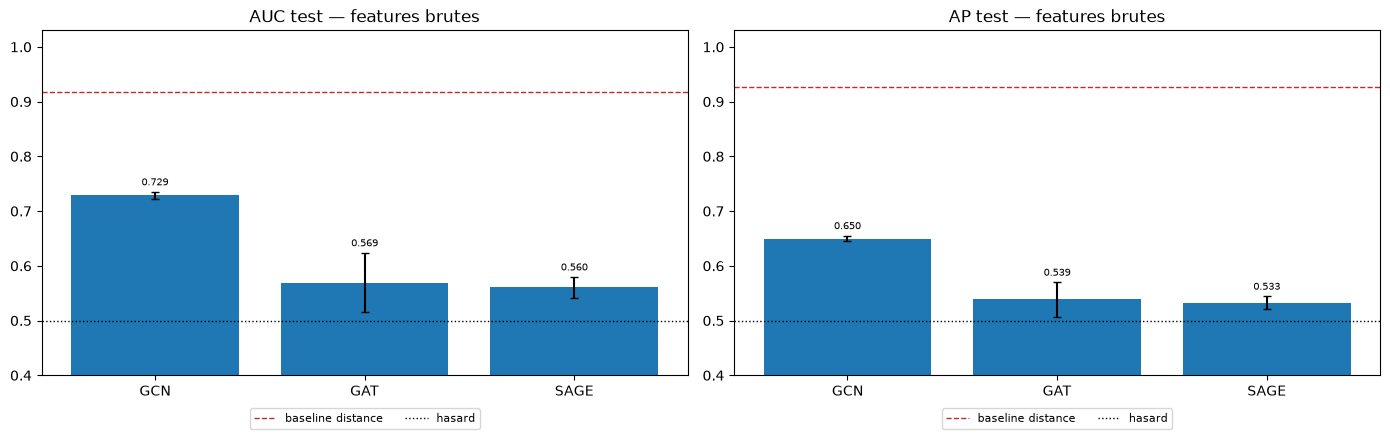

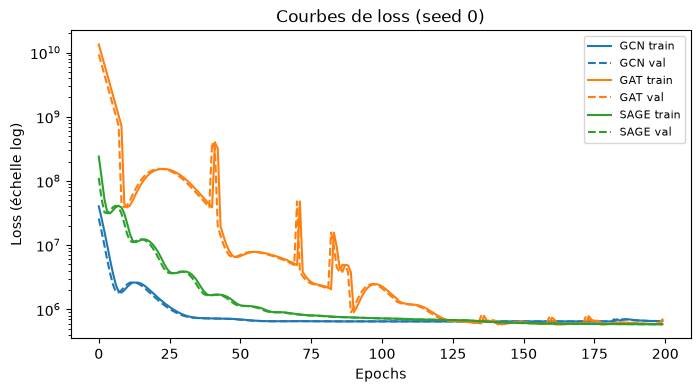


Matrice de confusion — GCN test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1258 1451]
 [  71 2638]]
Perf : AUC 0.7223 (vrai_positif/faux_positif) - AP 0.6443 ( précision/rappel )

Matrice de confusion — GAT test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[ 523 2186]
 [ 116 2593]]
Perf : AUC 0.5752 (vrai_positif/faux_positif) - AP 0.5408 ( précision/rappel )

Matrice de confusion — SAGE test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[1083 1626]
 [ 641 2068]]
Perf : AUC 0.5816 (vrai_positif/faux_positif) - AP 0.5457 ( précision/rappel )


In [9]:
tracer_barres(df_convs, "couche", titre="features brutes")
tracer_loss(historiques_convs, "Courbes de loss (seed 0)")
for nom, model in modeles_convs.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")

### Interprétation

- **Avec les features brutes, GCN (0.729) est nettement meilleur que GAT (0.570) et SAGE (0.560)**, qui sont à peine au-dessus du hasard, avec une forte variabilité entre seeds pour GAT.
- **Courbes de loss :** la loss initiale est énorme (~1e7 pour GCN, ~1e10 pour GAT) et l'entraînement de GAT est très instable (pics). La population (jusqu'à 2.2e7) produit des activations gigantesques. GAT calcule ses coefficients d'attention directement à partir de ces valeurs, et SAGE ajoute les features brutes du nœud lui-même sans normalisation : ces deux couches y sont plus sensibles. GCN, qui fait une moyenne normalisée par le degré, s'en sort mieux.
- **Aucun modèle n'atteint la baseline distance (0.918)** : avec les features brutes, le VGAE apprend moins qu'une simple règle géographique.

## 4. Amélioration des features

Les features brutes posent deux problèmes :

**1. Des échelles très différentes.** Longitude et latitude sont autour de ±180, alors que la population va de ~600 à ~2.2e7. Les poids du réseau doivent compenser ces écarts, ce qui rend l'optimisation difficile.
→ **Normalisation** : `log(1 + pop)` pour réduire l'écart entre petites et grandes villes, puis **standardisation** de chaque colonne (moyenne 0, écart-type 1).

**2. La longitude est circulaire.** −179° et +179° sont à quelques kilomètres l'un de l'autre, mais pour le modèle leur différence vaut 358° (Pacifique, Alaska, extrême-orient russe).
→ **Coordonnées 3D** : on remplace (lon, lat) par la position du point sur une sphère de rayon 1, avec $\varphi$ la latitude et $\lambda$ la longitude en radians :

$$x = \cos\varphi \cdot \cos\lambda \qquad y = \cos\varphi \cdot \sin\lambda \qquad z = \sin\varphi$$

Deux aéroports proches sur le globe ont maintenant des coordonnées $(x, y, z)$ proches. Les valeurs sont déjà entre −1 et 1, donc pas besoin de les standardiser.

**Information supplémentaire : le pays.** Les routes intérieures sont très fréquentes. Chaque pays devient un vecteur **one-hot** de taille 212 (nombre de pays). *Pourquoi pas un embedding ?* La première couche de l'encodeur multiplie les features par une matrice de poids $W$ : multiplier un vecteur one-hot par $W$ revient à **sélectionner la ligne de $W$ du pays**. Le modèle apprend donc automatiquement un embedding par pays, sans modifier l'encodeur.

| Jeu de features | Contenu | Dimension |
|---|---|---|
| brutes (section 3) | lon, lat, population | 3 |
| normalisées | lon, lat, log(pop), standardisés | 3 |
| 3D | x, y, z, log(pop) standardisée | 4 |
| 3D + pays | x, y, z, log(pop) standardisée, one-hot du pays | 216 |

On relance la comparaison GCN / GAT / SAGE de la section 3 (mêmes dimensions, lr, époques et seeds) avec chaque jeu de features.

Les features des nœuds sont les mêmes dans les 3 splits (seules les arêtes changent) : on les calcule une seule fois.

In [10]:
x_brut = train_data.x.float()

# Normalisation : log(1 + population), puis standardisation de chaque colonne
x_log = x_brut.clone()
x_log[:, 2] = th.log1p(x_log[:, 2])
x_normalise = (x_log - x_log.mean(dim=0)) / x_log.std(dim=0)
log_pop = x_normalise[:, 2:3]

# Coordonnées 3D sur la sphère
lon_rad = th.deg2rad(x_brut[:, 0])
lat_rad = th.deg2rad(x_brut[:, 1])
coord_3d = th.stack([
    th.cos(lat_rad) * th.cos(lon_rad),  # x
    th.cos(lat_rad) * th.sin(lon_rad),  # y
    th.sin(lat_rad),                    # z
], dim=1)

# One-hot du pays : chaque pays reçoit un indice (LabelEncoder), puis on crée le vecteur one-hot
indices_pays = th.tensor(LabelEncoder().fit_transform(train_data.country))
pays_one_hot = F.one_hot(indices_pays).float()

features = {
    "normalisées": x_normalise,
    "3D": th.cat([coord_3d, log_pop], dim=1),
    "3D + pays": th.cat([coord_3d, log_pop, pays_one_hot], dim=1),
}

def avec_features(donnees, x):
    # même graphe et mêmes paires à prédire, seules les features des nœuds changent
    donnees_bis = copy.copy(donnees)
    donnees_bis.x = x
    return donnees_bis

colonnes = ["longitude", "latitude", "population"]
print("Features brutes :\n", pd.DataFrame(x_brut.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))
print("\nFeatures normalisées :\n", pd.DataFrame(x_normalise.numpy(), columns=colonnes).describe().loc[["mean", "std", "min", "max"]].round(2))

print()
for nom, x in features.items():
    print(f"{nom} : {x.size(1)} features par aéroport")

# Exemple : -179° et +179° de longitude sont loin en (lon, lat) mais proches en 3D
print()
for lon in [-179.0, 179.0]:
    l = th.deg2rad(th.tensor(lon))
    print(f"lon = {lon:+.0f}°, lat = 0° -> (x, y, z) = ({th.cos(l):.3f}, {th.sin(l):.3f}, 0.000)")

# Pourquoi le pays est utile : part des paires dans le même pays, vraies routes vs paires négatives
print()
for titre, paires in [("vraies routes", test_data.pos_edge_label_index), ("paires négatives", test_data.neg_edge_label_index)]:
    meme_pays = (indices_pays[paires[0]] == indices_pays[paires[1]]).float().mean()
    print(f"Test, {titre} : {meme_pays:.1%} relient deux aéroports du même pays")

Features brutes :
       longitude  latitude   population
mean       0.70     23.02    338077.66
std       96.47     29.33   1262323.12
min     -179.87    -54.82       637.00
max      179.90     78.25  22315474.00

Features normalisées :
       longitude  latitude  population
mean       0.00      0.00        0.00
std        1.00      1.00        1.00
min       -1.87     -2.65       -2.31
max        1.86      1.88        3.46

normalisées : 3 features par aéroport
3D : 4 features par aéroport
3D + pays : 216 features par aéroport

lon = -179°, lat = 0° -> (x, y, z) = (-1.000, -0.017, 0.000)
lon = +179°, lat = 0° -> (x, y, z) = (-1.000, 0.017, 0.000)

Test, vraies routes : 57.4% relient deux aéroports du même pays
Test, paires négatives : 5.5% relient deux aéroports du même pays


In [11]:
# Les résultats « brutes » sont ceux de la section 3 : on ne relance que les 3 nouveaux jeux de features
resultats_features = [{"features": "brutes", **r} for r in resultats_convs]
historiques_features, modeles_features = {}, {}
for nom_features, x in features.items():
    splits = tuple(avec_features(d, x) for d in (train_data, val_data, test_data))
    for nom, conv in convs.items():
        resultats, historiques_features[(nom_features, nom)], modeles_features[(nom_features, nom)] = \
            lancer_experience(splits, conv)
        resultats_features += [{"features": nom_features, "couche": nom, **r} for r in resultats]
        print(f"{nom_features} - {nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))

df_features = pd.DataFrame(resultats_features)
tableau_features = (df_features.groupby(["couche", "features"], sort=False)[["AUC", "AP"]].mean()
                    .unstack("features").round(4))
tableau_features

normalisées - GCN : AUC test = 0.9593, 0.9594, 0.9564


normalisées - GAT : AUC test = 0.9064, 0.9050, 0.9059


normalisées - SAGE : AUC test = 0.9169, 0.9214, 0.9131


3D - GCN : AUC test = 0.9735, 0.9698, 0.9730


3D - GAT : AUC test = 0.9157, 0.9097, 0.9173


3D - SAGE : AUC test = 0.9236, 0.9150, 0.9226


3D + pays - GCN : AUC test = 0.9753, 0.9766, 0.9750


3D + pays - GAT : AUC test = 0.9217, 0.9170, 0.9238


3D + pays - SAGE : AUC test = 0.9251, 0.9243, 0.9237


AUC                                    AP                      \
features  brutes normalisées      3D 3D + pays  brutes normalisées      3D   
couche                                                                       
GCN       0.7290      0.9584  0.9721    0.9756  0.6499      0.9616  0.9724   
GAT       0.5695      0.9058  0.9143    0.9208  0.5387      0.8873  0.8949   
SAGE      0.5604      0.9171  0.9204    0.9244  0.5328      0.9237  0.9294   

                    
features 3D + pays  
couche              
GCN         0.9765  
GAT         0.9089  
SAGE        0.9232

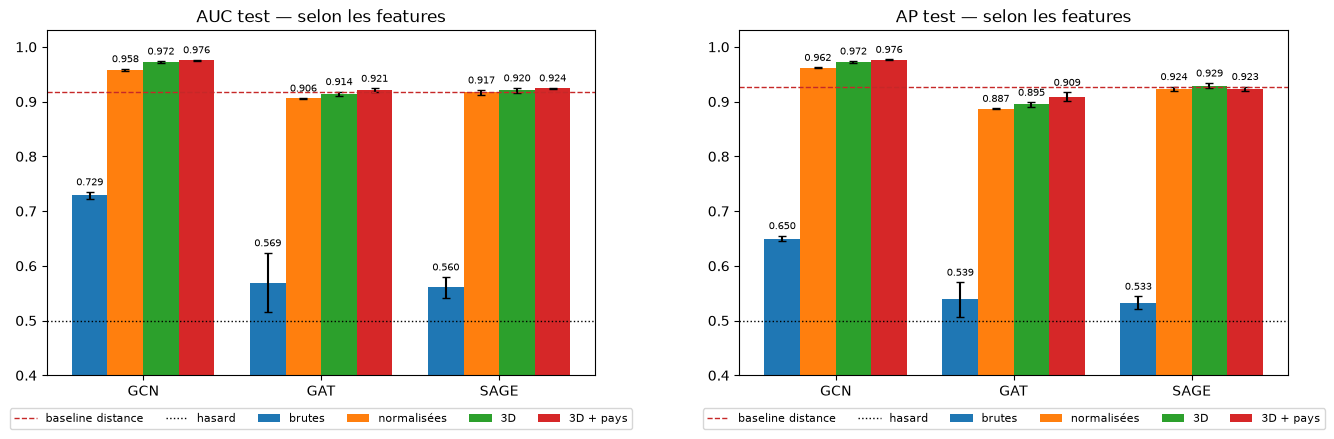

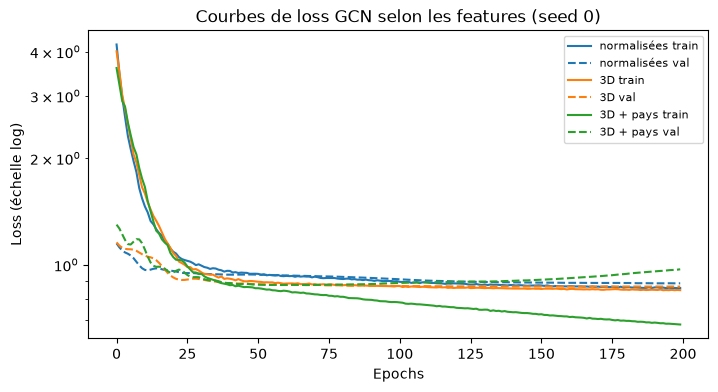

In [12]:
tracer_barres(df_features, "couche", "features", titre="selon les features")
tracer_loss({nom: historiques_features[(nom, "GCN")] for nom in features}, "Courbes de loss GCN selon les features (seed 0)")

### Interprétation

- **La normalisation change tout :** GCN passe de 0.729 à 0.958 d'AUC (+23 points), GAT et SAGE de ~0.56 à ~0.91 (+35 points). Les trois modèles dépassent ou atteignent alors la baseline.
- **Les coordonnées 3D apportent un gain supplémentaire**, surtout pour GCN (0.958 → 0.972) : le modèle n'a plus à « deviner » que −179° et +179° sont voisins.
- **Le pays apporte un dernier gain, plus modeste** (GCN 0.976). Le signal est pourtant fort (57 % des vraies routes sont intérieures, contre 5.5 % des paires négatives), mais une bonne partie de cette information est déjà contenue dans la position géographique. Pour SAGE, l'AP baisse même légèrement.
- **GCN reste nettement le meilleur avec tous les jeux de features.** GAT et SAGE dépassent à peine la baseline en AUC (0.921 et 0.924 contre 0.918) et GAT reste en dessous en AP.
- **Limite du one-hot :** il fait passer de 4 à 216 features, et 62 pays n'ont qu'un seul aéroport (leur colonne n'apporte presque rien). Regrouper les pays par continent ou région serait une variante plus compacte.

## 5. Synthèse

On reprend, pour chaque étape du notebook, la meilleure configuration (moyenne sur les seeds), et on la compare à la baseline.

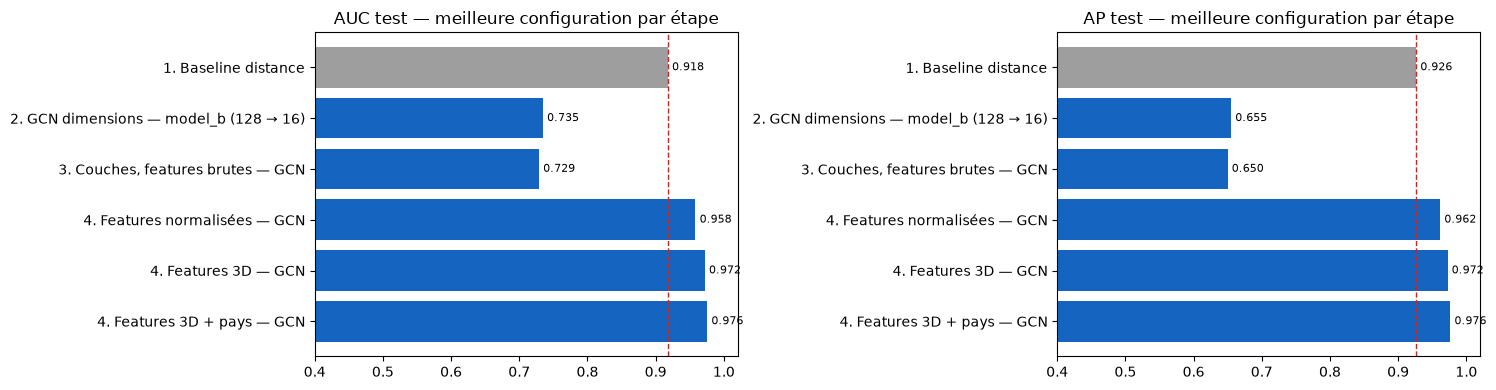

,étape,AUC,AP
0,1. Baseline distance,0.9179,0.9264
1,2. GCN dimensions — model_b (128 → 16),0.7347,0.6550
2,"3. Couches, features brutes — GCN",0.7290,0.6499
3,4. Features normalisées — GCN,0.9584,0.9616
4,4. Features 3D — GCN,0.9721,0.9724
5,4. Features 3D + pays — GCN,0.9756,0.9765


In [13]:
def meilleure_config(df, colonnes):
    # configuration avec la meilleure AUC moyenne sur les seeds
    moyennes = df.groupby(colonnes, sort=False)[["AUC", "AP"]].mean()
    meilleure = moyennes["AUC"].idxmax()
    return meilleure, moyennes.loc[meilleure]

etapes = [{"étape": "1. Baseline distance", "AUC": baseline["AUC"], "AP": baseline["AP"]}]
nom, perf = meilleure_config(df_dimensions, "modele")
etapes.append({"étape": f"2. GCN dimensions — {nom}", **perf})
nom, perf = meilleure_config(df_convs, "couche")
etapes.append({"étape": f"3. Couches, features brutes — {nom}", **perf})
for nom_features in features:
    nom, perf = meilleure_config(df_features[df_features["features"] == nom_features], "couche")
    etapes.append({"étape": f"4. Features {nom_features} — {nom}", **perf})

df_synthese = pd.DataFrame(etapes)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, metrique in zip(axes, ["AUC", "AP"]):
    couleurs = ["#9e9e9e"] + ["#1565c0"] * (len(df_synthese) - 1)
    barres = ax.barh(df_synthese["étape"][::-1], df_synthese[metrique][::-1], color=couleurs[::-1])
    ax.bar_label(barres, fmt="%.3f", padding=3, fontsize=8)
    ax.axvline(baseline[metrique], color="#c62828", linestyle="--", linewidth=1)
    ax.set_xlim(0.4, 1.02)
    ax.set_title(f"{metrique} test — meilleure configuration par étape")
plt.tight_layout()
plt.show()

df_synthese.round(4)

### Conclusion

- **La baseline distance est très forte (AUC 0.918)** parce que les paires négatives sont tirées au hasard, donc surtout très éloignées. C'est la référence à battre.
- **Faire varier les dimensions (section 2) ou la couche de convolution (section 3) ne suffit pas** tant que les features sont brutes : tous les modèles restent sous la baseline.
- **Le pré-traitement des features est le facteur décisif** : normalisation (+23 points), puis coordonnées 3D et pays. Le meilleur modèle, **VGAE-GCN avec features 3D + pays**, atteint **0.976 d'AUC et d'AP**, soit environ 6 points au-dessus de la baseline.
- **GCN est la meilleure couche dans toutes les configurations testées.**

**Pistes pour aller plus loin :**
- évaluer avec des **négatifs difficiles** (paires proches mais non reliées), pour un test plus réaliste et plus discriminant ;
- visualiser les embeddings $z$ (t-SNE coloré par continent) ;
- examiner les routes prédites avec le score le plus élevé qui n'existent pas dans le graphe ;
- répéter l'expérience sur plusieurs splits `RandomLinkSplit`, et pas seulement plusieurs seeds.